# Forest Fires Data Analysis with SHAP Explanations

This notebook loads forest fires data, trains a RandomForestRegressor model, and explains predictions using SHAP TreeExplainer.

## Section 1: Import Required Libraries

Import pandas for data loading, scikit-learn for model training, and SHAP for model explanation.

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

/home/fernandeza/Escritorio/Practicas/DV/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Section 2: Load and Explore the Data

Load the forestfires.csv dataset using pandas, display basic information about the dataset, check for missing values, and examine the first few rows.

In [2]:
# Load the dataset
df = pd.read_csv('./data/forestfires.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst Few Rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
print(df.describe())

Dataset Shape: (517, 13)

First Few Rows:
   X  Y month  day  FFMC   DMC     DC  ISI  temp  RH  wind  rain  area
0  7  5   mar  fri  86.2  26.2   94.3  5.1   8.2  51   6.7   0.0   0.0
1  7  4   oct  tue  90.6  35.4  669.1  6.7  18.0  33   0.9   0.0   0.0
2  7  4   oct  sat  90.6  43.7  686.9  6.7  14.6  33   1.3   0.0   0.0
3  8  6   mar  fri  91.7  33.3   77.5  9.0   8.3  97   4.0   0.2   0.0
4  8  6   mar  sun  89.3  51.3  102.2  9.6  11.4  99   1.8   0.0   0.0

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    str    
 3   day     517 non-null    str    
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517

## Section 3: Prepare Data for Modeling and train RandomForestRegressor Model



In [3]:
# We keep only the meteorological variables for a clean visual analysis to avoid clutter
features = ['temp', 'RH', 'wind', 'rain']
X = df[features]

# The target variable 'area' is highly skewed towards 0.
# We apply a logarithmic transformation to smooth the prediction and improve the model.
y = np.log1p(df['area']) 

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data prepared. Training set size: {X_train.shape[0]} samples.")

# Train the RandomForest model
model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Explainability with SHAP
print("Calculating SHAP values...")
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap_values_local = explainer(X_test) # Required for the local waterfall plot
print("Calculation completed!\n")

Data prepared. Training set size: 413 samples.
Calculating SHAP values...
Calculation completed!



## Section 4: Generate and Visualize SHAP Explanations

Generate SHAP values for predictions, create visualizations such as summary plots and force plots to interpret model behavior and feature importance.

Global plot exported successfully as 'shap_summary_plot.jpg'


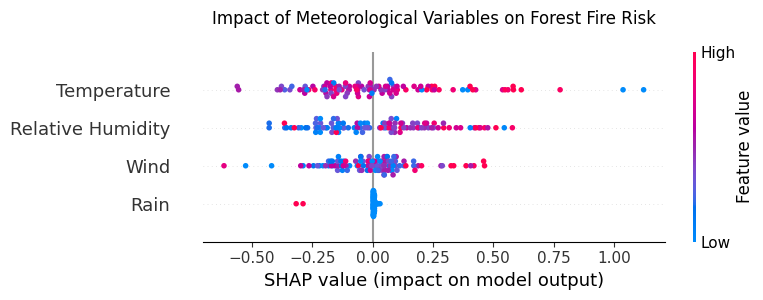

In [4]:
plt.figure(figsize=(8, 6))

# Create the classic beeswarm plot to show density, direction, and impact
shap.summary_plot(shap_values, X_test, 
                  feature_names=['Temperature', 'Relative Humidity', 'Wind', 'Rain'], 
                  show=False)

plt.title("Impact of Meteorological Variables on Forest Fire Risk", fontsize=12, pad=20)
plt.tight_layout()

# Export as vector jpg 
plt.savefig("./plots/shap_summary_plot.jpg", format="jpg", dpi=300, bbox_inches='tight')
print("Global plot exported successfully as 'shap_summary_plot.jpg'")
plt.show()



Local plot exported successfully as 'shap_waterfall_local.jpg'


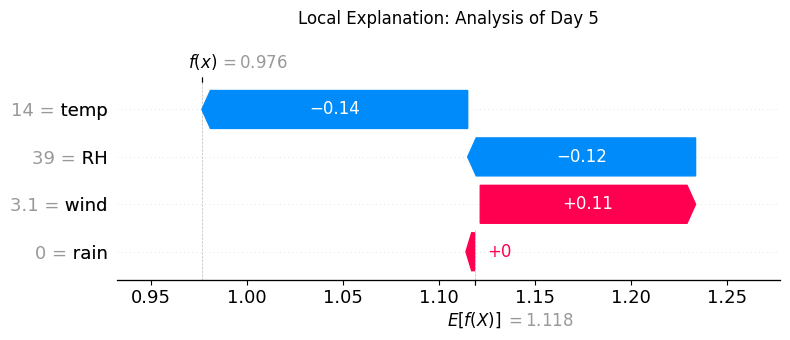

In [5]:
# We choose a specific day from the test set (index 5)
day_idx = 5

plt.figure(figsize=(8, 5))
shap.plots.waterfall(shap_values_local[day_idx], show=False)

plt.title(f"Local Explanation: Analysis of Day {day_idx}", fontsize=12, pad=20)
plt.tight_layout()

# Export as JPG 
plt.savefig("./plots/shap_waterfall_local.jpg", format="jpg", dpi=300, bbox_inches='tight')
print("Local plot exported successfully as 'shap_waterfall_local.jpg'")
plt.show()
